# Temperature data EDA (for specific date and time range)

In [17]:
# Imports
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.dates import DateFormatter, HourLocator

from temp_data_plot_functions import plot_hot_water, plot_room_temp, plot_power, plot_tariff

In [18]:
matplotlib.rcParams.update({'font.size': 23})

In [19]:
# Read in, sort and store data to use for problem
temp_path = Path("data/PSTData5")
temp_files = temp_path.glob("*.csv")

houses_temps = {}
zone_2 = True
for file in temp_files:
    if "Events" not in str(file):
        house_id = file.stem.split("_")[0]
        data = pd.read_csv(file)
        # Store data
        data["Datetime"] = pd.to_datetime(data["Time (UTC)"])
        houses_temps[house_id] = data


In [34]:
house_id = "30055" # with start_index=1871
# house_id = "30436"  # with start_index=22466
temp_df = houses_temps[house_id]

In [35]:
# Slice parameters
start_index = 1871  # note: easiest to extract this as the row index in the excel file... could be automated
num_hours = 3*24 # 30  # Number of hours to plot
end_index = int(start_index+(num_hours*60/5))

In [36]:
def setup_plot(df, house_id, start_index, end_index, power=False):
    """Set up figure with subplots for plotting
    
    Args:
        df (Dataframe): dataframe of a house to plot
        house_id (str): id of house to plot
        start_index (int): index at start of data to begin plot from
        end_index (int): index at end of data to end plot at

    Returns:
        temp_plot (matplotlib subplot): subplot to plot room temperature variables
        hot_water_plot (matplotlib subplot): subplot to plot hot water variables
        tariff_plot (matplotlib subplot): subplot to plot tariff
    
    """
    if power:
        fig, (temp_plot, hot_water_plot, power_plot, tariff_plot) = plt.subplots(4, 1, sharex=True, height_ratios=[5, 5, 5, 3], figsize=(20,12))  #, layout="tight")
    else:
        fig, (temp_plot, hot_water_plot, tariff_plot) = plt.subplots(3, 1, sharex=True, height_ratios=[5, 5, 3], figsize=(20, 8))  #, layout="tight")
    plt.xlim(df["Datetime"][start_index],df["Datetime"][end_index])
    # fig.suptitle(f"House: {house_id}")
    plt.xlabel("Time")
    ax = fig.gca()
    ax.xaxis.set_major_formatter(DateFormatter("%d %b %H:%M"))
    ax.xaxis.set_major_locator(HourLocator(interval=6))

    # ax.xaxis.set_major_locator(DayLocator(interval=1))
    # ax.xaxis.set_major_formatter(DateFormatter('%d/%m/%y'))
    plt.xticks(rotation=30, ha="right")
    
    if power:
        return temp_plot, hot_water_plot, power_plot, tariff_plot
    else:
        return temp_plot, hot_water_plot, tariff_plot

In [50]:
def plot_temp_data(df, house_id, start_index, end_index, power=False):
    """Plot the temperature data by either week or day

    Args:
        df (Dataframe): data for plotting
        house_id (str): id of house to plot
        start_index (int): index at start of data to begin plot from
        end_index (int): index at end of data to end plot at

    Returns:
        Plots of the temperature data for a specific set of hours
    """
    # Get data
    dates = df["Datetime"][start_index:end_index]
    room_temp_z1 = df["Room temperature (Zone 1) (°C)"][start_index:end_index]
    user_setpoint_z1 = df["Setpoint temperature (Zone 1) (°C)"][start_index:end_index]
    
    room_temp_z2 = df["Room temperature (Zone 2) (°C)"][start_index:end_index]
    user_setpoint_z2 = df["Setpoint temperature (Zone 2) (°C)"][start_index:end_index]
    if len(room_temp_z2.unique()) == 1:  # Checks if all zone 2 data is Nans
        room_temp_z2 = None
        user_setpoint_z2 = None
    
    flow_temp = df["Flow temperature (°C)"][start_index:end_index]
    hot_water_temp = df["Hot water temperature (°C)"][start_index:end_index]
    hot_water_setpoint = df["Hot water setpoint (°C)"][start_index:end_index]
    
    try: 
        ext_temp = df["External temperature (°C)"][start_index:end_index]
    except:  # noqa: E722
        ext_temp = None
    tariff = df["Tariff rate (p/kWh)"][start_index:end_index]

    # Make subfigs
    if power:
        input_power = df["Power consumption (kW)"][start_index:end_index]
        temp_plot, hot_water_plot, power_plot, tariff_plot = setup_plot(df, house_id, start_index, end_index, power=True)
        plot_power(power_plot, dates, input_power)
    else:
        temp_plot, hot_water_plot, tariff_plot = setup_plot(df, house_id, start_index, end_index)

    # Plot on subfigs
    plot_room_temp(temp_plot, dates, room_temp_z1, user_setpoint_z1, room_temp_z2, user_setpoint_z2, flow_temp, ext_temp)
    plot_hot_water(hot_water_plot, dates, hot_water_temp, hot_water_setpoint, flow_temp)
    plot_tariff(df, tariff_plot, dates, tariff)

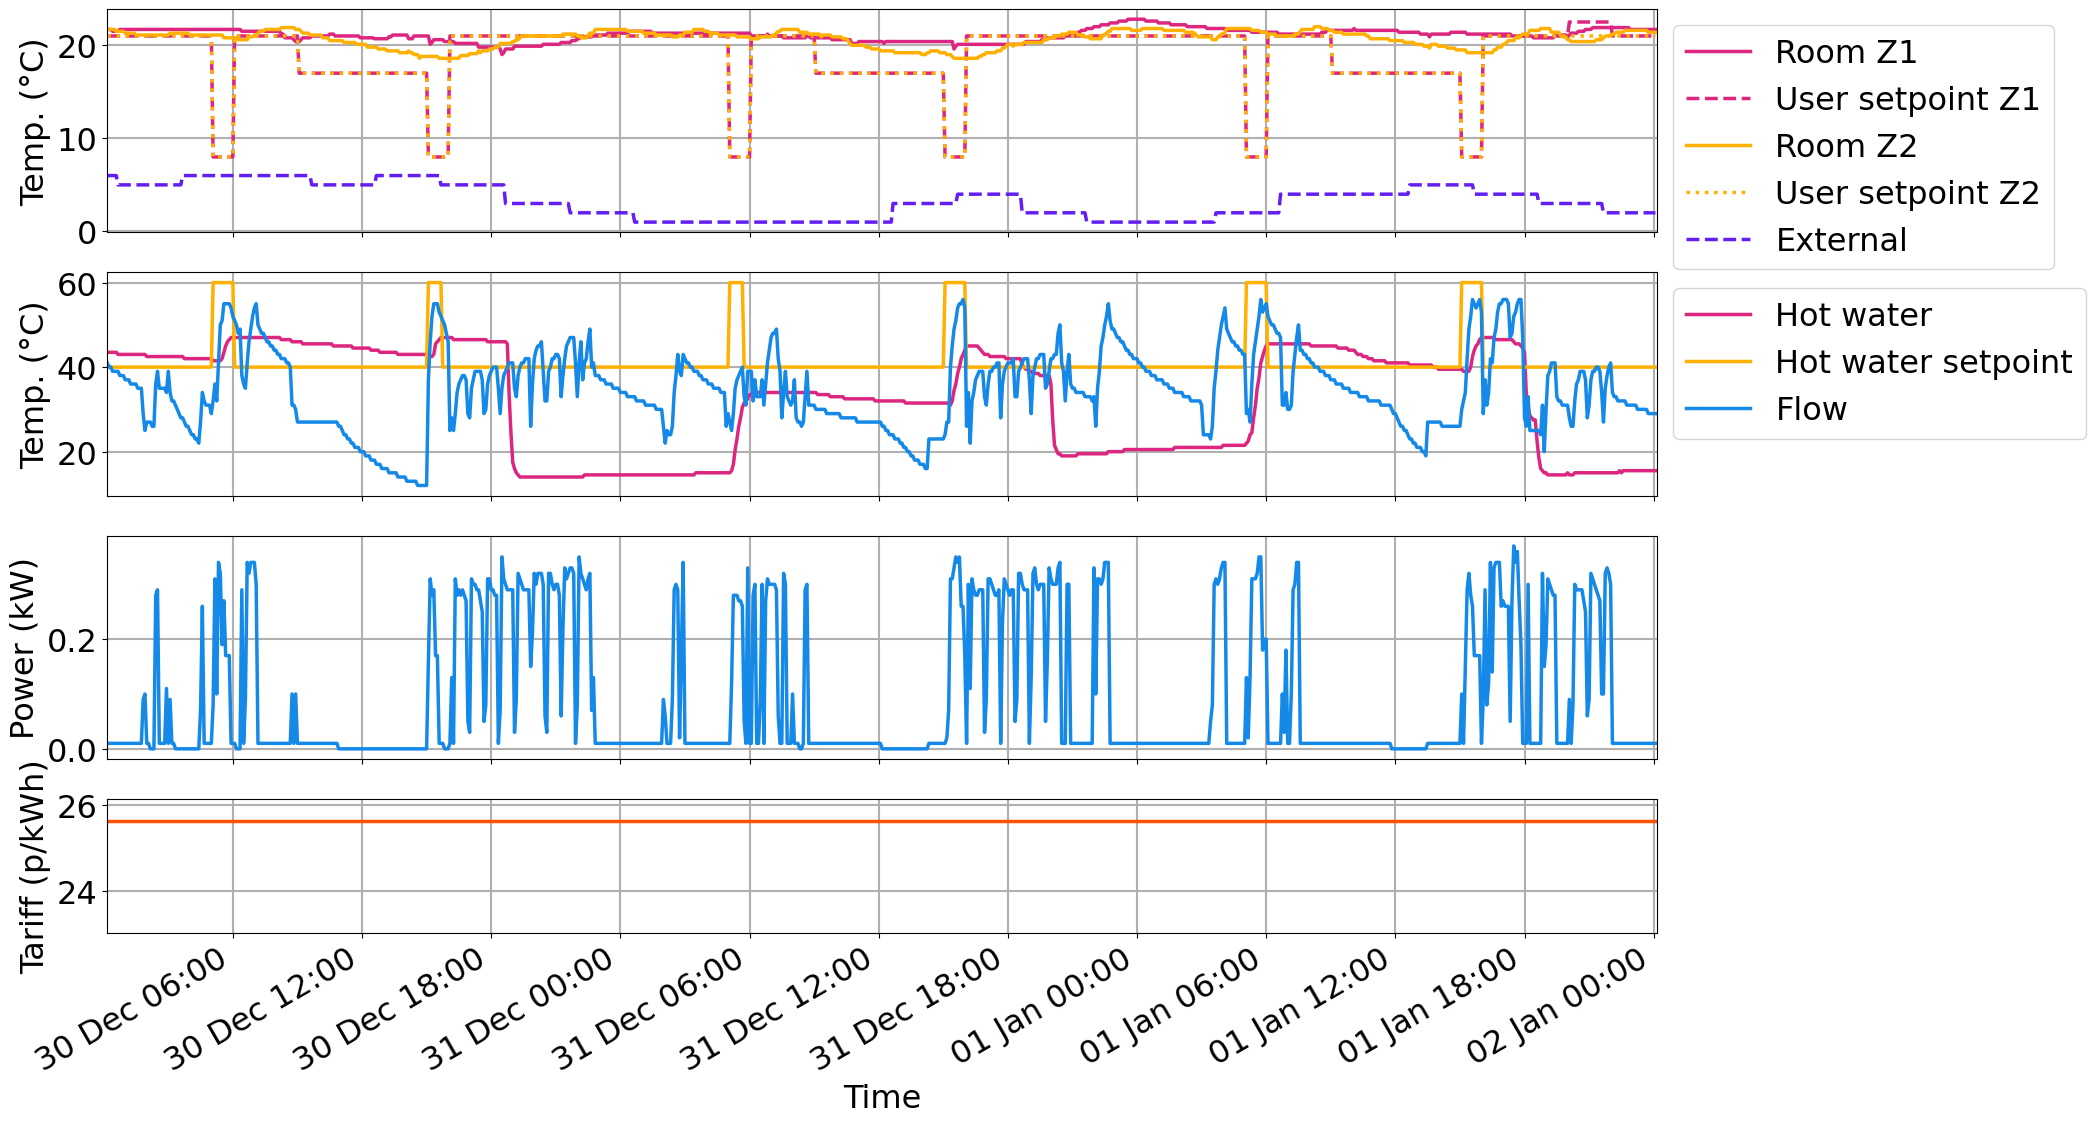

In [51]:
plot_temp_data(temp_df, house_id, start_index, end_index, power=True)